In [60]:
import kagglehub
import os
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')
# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/solow/.cache/kagglehub/datasets/mosapabdelghany/medical-insurance-cost-dataset/versions/1


In [61]:
file=os.listdir(path=path)
file=os.path.join(path,file[0])
df=pd.read_csv(file)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [64]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [65]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [66]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [67]:
df_original=df.copy()

In [68]:
df['charges']=round(df['charges'],2)
df['bmi']=round(df['bmi'],2)

In [69]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55
1334,18,female,31.92,0,no,northeast,2205.98
1335,18,female,36.85,0,no,southeast,1629.83
1336,21,female,25.80,0,no,southwest,2007.94


In [70]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [71]:
df['sex']=df['sex'].map({'female':0,'male':1})
df['smoker']=df['smoker'].map({'no':0,'yes':1})

In [72]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,southwest,16884.92
1,18,1,33.77,1,0,southeast,1725.55
2,28,1,33.00,3,0,southeast,4449.46
3,33,1,22.70,0,0,northwest,21984.47
4,32,1,28.88,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,1,30.97,3,0,northwest,10600.55
1334,18,0,31.92,0,0,northeast,2205.98
1335,18,0,36.85,0,0,southeast,1629.83
1336,21,0,25.80,0,0,southwest,2007.94


In [73]:
df[df["children"].between(0, 5)]["sex"].value_counts()

sex
1    676
0    662
Name: count, dtype: int64

In [74]:
pd.crosstab(df["children"], df["sex"])

sex,0,1
children,,
0,289,285
1,158,166
2,119,121
3,77,80
4,11,14
5,8,10


In [75]:
numerical_col=['age','bmi','children']

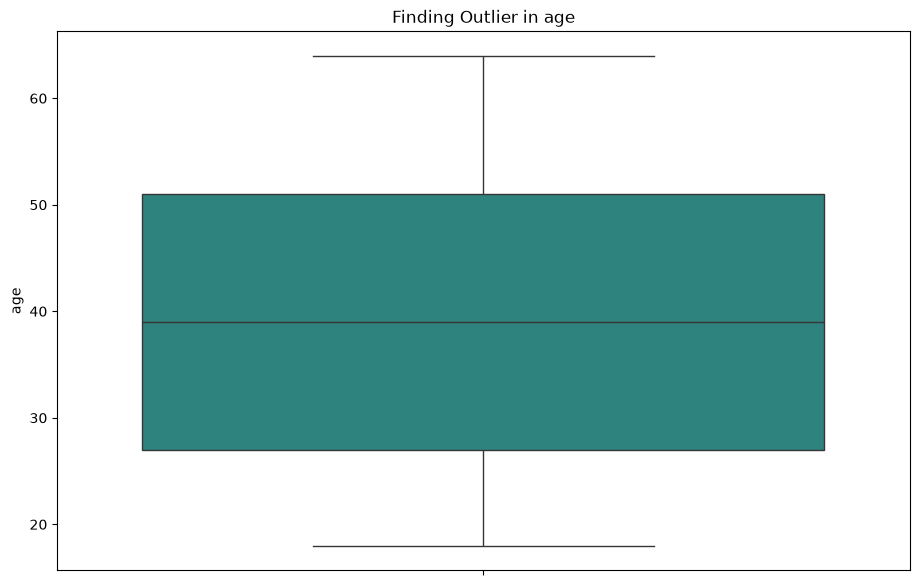

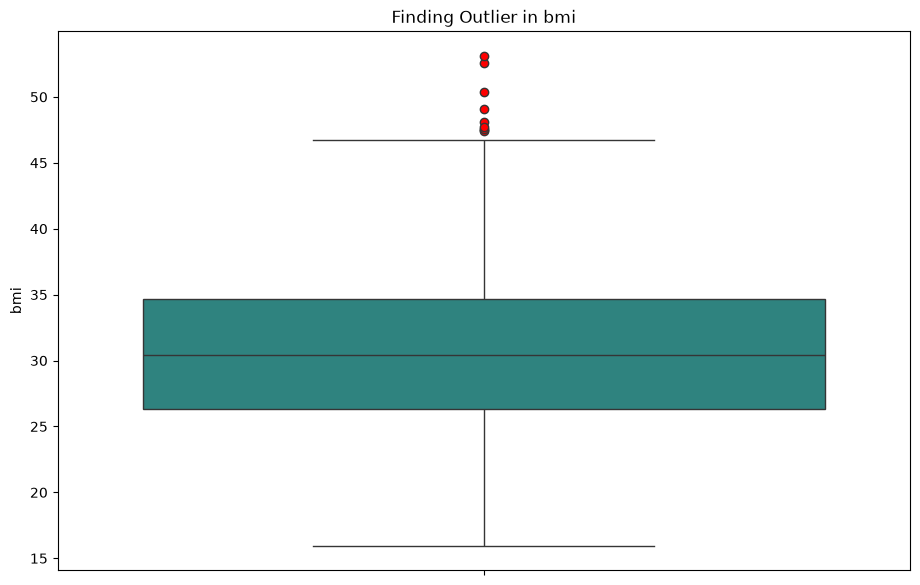

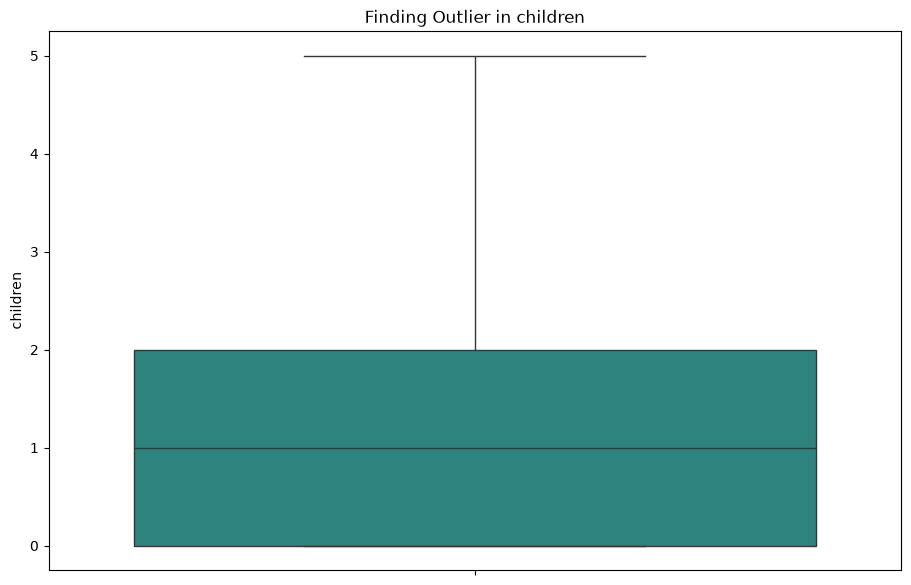

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
for each in numerical_col:
    fig,ax=plt.subplots(figsize=(11,7))
    sns.boxplot(df[each],palette='viridis',ax=ax,flierprops={"markerfacecolor": "red"})
    ax.set_title(f'Finding Outlier in {each}')
    plt.show()

In [77]:
q1 = df["bmi"].quantile(0.25)
q3 = df["bmi"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

bmi_outliers = df[(df["bmi"] < lower) |(df["bmi"] > upper)]

print(len(bmi_outliers))

9


<Axes: xlabel='charges', ylabel='Count'>

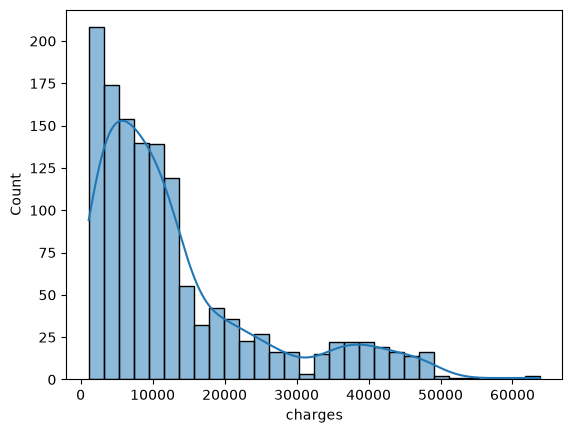

In [78]:
sns.histplot(df["charges"], kde=True)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 73.3 KB


In [80]:
((1338-1191)/1191)*100 

12.34256926952141

In [81]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,southwest,16884.92
1,18,1,33.77,1,0,southeast,1725.55
2,28,1,33.00,3,0,southeast,4449.46
3,33,1,22.70,0,0,northwest,21984.47
4,32,1,28.88,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,1,30.97,3,0,northwest,10600.55
1334,18,0,31.92,0,0,northeast,2205.98
1335,18,0,36.85,0,0,southeast,1629.83
1336,21,0,25.80,0,0,southwest,2007.94


In [82]:
df['bmi'].skew()

np.float64(0.28410490896525215)

In [83]:
numerical_col
binary_col=['sex','smoker']
onehot_col=['region']
target='charges'

In [84]:
feature=numerical_col+binary_col+onehot_col
len(feature)

6

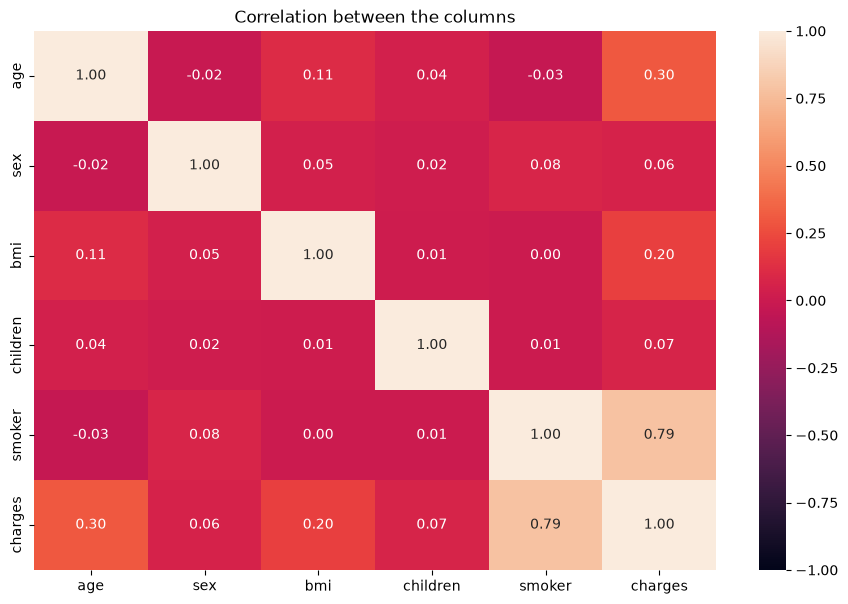

In [85]:
fig,ax=plt.subplots(figsize=(11,7))
sns.heatmap(df.corr(numeric_only=True),vmax=1,vmin=-1,annot=True,ax=ax,fmt='.2f')
ax.set_title('Correlation between the columns')
plt.show()

In [86]:
x=df[feature]
y=df['charges']

In [87]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=24,test_size=.20)

make the preprocesing trnaformer for the scaling and tree algorithum

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
scaled_preprocessing=ColumnTransformer(transformers=[('numerical',StandardScaler(),numerical_col),
                                                     ('onehot',OneHotEncoder(handle_unknown='ignore'),onehot_col)],remainder='passthrough')

tree_preprocessing=ColumnTransformer(transformers=[('onehot_tree',OneHotEncoder(handle_unknown='ignore'),onehot_col)],remainder='passthrough')


In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor as gbr
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
##linear and knn
linear_pipeline=Pipeline([('preprocessor',scaled_preprocessing),
                          ('model',LinearRegression())])
knn_pipeline=Pipeline([('preprocessor',scaled_preprocessing),
                        ('model',KNeighborsRegressor())])
##tree
dt_pipeline=Pipeline([('preprocessor',tree_preprocessing),
                      ('model',DecisionTreeRegressor(random_state=42))])
rf_pipeline=Pipeline([('preprocessor',tree_preprocessing),
                      ('model',RandomForestRegressor(random_state=42))])
grb_pipeline=Pipeline([('preprocessor',tree_preprocessing),
                       ('model',gbr())])
ada_pipeline=Pipeline([('preprocessor',tree_preprocessing),
                       ('model',AdaBoostRegressor())])
xgb_pipeline=Pipeline([('preprocessor',tree_preprocessing),
                       ('model',XGBRegressor())])
lgbm_pipeline=Pipeline([('preprocessor',tree_preprocessing),
                        ('model',LGBMRegressor())])

param_distribution for each tree algo

In [90]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

gradient boosting

In [91]:
import optuna
from sklearn.model_selection import cross_val_score

def objective_gb(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 500
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 2, 8
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        )
    }

    model = gbr(
        **params,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", tree_preprocessing),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()

In [92]:
study_gb = optuna.create_study(
    study_name="GradientBoosting_Optimization",
    direction="minimize",
    storage="sqlite:///optuna.db",
    load_if_exists=True
)

study_gb.optimize(
    objective_gb,
    n_trials=50
)


[I 2026-10-03 01:24:08,812] A new study created in RDB with name: GradientBoosting_Optimization
[I 2026-10-03 01:24:08,986] Trial 0 finished with value: 4741.5444394924325 and parameters: {'n_estimators': 62, 'learning_rate': 0.10068393923801346, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 7, 'subsample': 0.9046913184838244}. Best is trial 0 with value: 4741.5444394924325.
[I 2026-10-03 01:24:09,229] Trial 1 finished with value: 4663.954699523307 and parameters: {'n_estimators': 284, 'learning_rate': 0.03661277325392317, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 6, 'subsample': 0.6254036696915498}. Best is trial 1 with value: 4663.954699523307.
[I 2026-10-03 01:24:09,464] Trial 2 finished with value: 4655.333980939899 and parameters: {'n_estimators': 277, 'learning_rate': 0.014007997522286611, 'max_depth': 2, 'min_samples_split': 6, 'min_samples_leaf': 7, 'subsample': 0.6699293461018914}. Best is trial 2 with value: 4655.333980939899.
[I 2026-10-03 0

In [93]:

print("Best RMSE:", study_gb.best_value)
print("Best Parameters:")
print(study_gb.best_params)

best_gb = gbr(
    **study_gb.best_params,
    random_state=42
)

best_gb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessing),
    ("model", best_gb)
])

best_gb_pipeline.fit(x_train, y_train)

y_pred = best_gb_pipeline.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Best RMSE: 4576.972449431373
Best Parameters:
{'n_estimators': 229, 'learning_rate': 0.017814488438936647, 'max_depth': 3, 'min_samples_split': 18, 'min_samples_leaf': 5, 'subsample': 0.6351026216235752}
MAE: 2332.48279949907
RMSE: 4114.871463205533
R2: 0.888768758657091


adaboosting

In [94]:
from sklearn.ensemble import AdaBoostRegressor

def objective_ada(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 500
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 1.0, log=True
        ),
        "loss": trial.suggest_categorical(
            "loss",
            ["linear", "square", "exponential"]
        )
    }

    model = AdaBoostRegressor(
        **params,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", tree_preprocessing),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()

In [95]:
study_ada = optuna.create_study(
    study_name="AdaBoost_Optimization",
    direction="minimize",
    storage="sqlite:///optuna.db",
    load_if_exists=True
)

study_ada.optimize(
    objective_ada,
    n_trials=50
)

[I 2026-10-03 01:24:22,707] A new study created in RDB with name: AdaBoost_Optimization
[I 2026-10-03 01:24:23,197] Trial 0 finished with value: 7956.410409379023 and parameters: {'n_estimators': 452, 'learning_rate': 0.05274277844478157, 'loss': 'square'}. Best is trial 0 with value: 7956.410409379023.
[I 2026-10-03 01:24:23,514] Trial 1 finished with value: 8547.689095529195 and parameters: {'n_estimators': 274, 'learning_rate': 0.163329671472696, 'loss': 'square'}. Best is trial 0 with value: 7956.410409379023.
[I 2026-10-03 01:24:23,978] Trial 2 finished with value: 6868.074371944531 and parameters: {'n_estimators': 433, 'learning_rate': 0.026573275229946444, 'loss': 'square'}. Best is trial 2 with value: 6868.074371944531.
[I 2026-10-03 01:24:24,425] Trial 3 finished with value: 8955.189170736043 and parameters: {'n_estimators': 454, 'learning_rate': 0.8101730532303119, 'loss': 'exponential'}. Best is trial 2 with value: 6868.074371944531.
[I 2026-10-03 01:24:24,680] Trial 4 finis

In [96]:

print("Best RMSE:", study_ada.best_value)
print("Best Parameters:")
print(study_ada.best_params)

best_ada = AdaBoostRegressor(
    **study_ada.best_params,
    random_state=42
)

best_ada_pipeline = Pipeline([
    ("preprocessor", tree_preprocessing),
    ("model", best_ada)
])

best_ada_pipeline.fit(x_train, y_train)

y_pred = best_ada_pipeline.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Best RMSE: 4811.321213083292
Best Parameters:
{'n_estimators': 57, 'learning_rate': 0.01013715760593248, 'loss': 'linear'}
MAE: 2942.7584843721843
RMSE: 4459.543465239604
R2: 0.8693543244129833


XGBoost

In [97]:
from xgboost import XGBRegressor

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 2, 12
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 0, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        )
    }

    # model = XGBRegressor(
    #     **params,
    #     objective="reg:squarederror",
    #     random_state=42,
    #     n_jobs=-1
    # )
    model = XGBRegressor(
    **params,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=42
)

    pipeline = Pipeline([
        ("preprocessor", tree_preprocessing),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()

In [98]:
study_xgb = optuna.create_study(
    study_name="XGBoost_Optimization",
    direction="minimize",
    storage="sqlite:///optuna.db",
    load_if_exists=True
)
study_xgb.optimize(
    objective_xgb,
    n_trials=50
)

[I 2026-10-03 01:24:34,320] A new study created in RDB with name: XGBoost_Optimization
[I 2026-10-03 01:24:37,657] Trial 0 finished with value: 5296.062899758389 and parameters: {'n_estimators': 404, 'max_depth': 5, 'learning_rate': 0.05917581376330401, 'min_child_weight': 1, 'subsample': 0.9404591073076636, 'colsample_bytree': 0.9684533860808745, 'gamma': 0.41652664575342013, 'reg_alpha': 0.13170852910828176, 'reg_lambda': 0.0054971299564203005}. Best is trial 0 with value: 5296.062899758389.
[I 2026-10-03 01:24:43,415] Trial 1 finished with value: 5000.995843604633 and parameters: {'n_estimators': 415, 'max_depth': 8, 'learning_rate': 0.016708279238891916, 'min_child_weight': 2, 'subsample': 0.793704243291913, 'colsample_bytree': 0.9015288721409505, 'gamma': 0.7865856511837154, 'reg_alpha': 6.386769206763548e-08, 'reg_lambda': 2.519932425345869e-06}. Best is trial 1 with value: 5000.995843604633.
[I 2026-10-03 01:24:46,093] Trial 2 finished with value: 4652.845467038025 and parameter

In [99]:

print("Best RMSE:", study_xgb.best_value)
print("Best Parameters:")
print(study_xgb.best_params)

best_gb = XGBRegressor(
    **study_xgb.best_params,
    random_state=42
)

best_xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessing),
    ("model", best_gb)
])

best_xgb_pipeline.fit(x_train, y_train)

y_pred = best_xgb_pipeline.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Best RMSE: 4593.332981343353
Best Parameters:
{'n_estimators': 290, 'max_depth': 3, 'learning_rate': 0.01939895058527237, 'min_child_weight': 9, 'subsample': 0.8938908065702749, 'colsample_bytree': 0.9480242207629798, 'gamma': 0.06704502005657789, 'reg_alpha': 0.5996714623403623, 'reg_lambda': 2.1691719640698714}
MAE: 2270.4571551422573
RMSE: 4105.286654758549
R2: 0.8892863390858732


LightGBM

In [102]:
from lightgbm import LGBMRegressor

def objective_lgbm(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 10, 100
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 50
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        )
    }

    model = LGBMRegressor(
        **params,
        random_state=42,
        verbosity=-1
    )
#     model = LGBMRegressor(
#     **params,
#     device="gpu",
#     random_state=42,
#     verbosity=-1
# )

    pipeline = Pipeline([
        ("preprocessor", tree_preprocessing),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()

In [103]:
study_lgbm = optuna.create_study(
    study_name="LightGBM_Optimization",
    direction="minimize",
    storage="sqlite:///optuna.db",
    load_if_exists=True
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=10
)

[I 2026-10-03 01:28:17,687] Using an existing study with `study_name='LightGBM_Optimization'` instead of creating a new one.
[I 2026-10-03 01:28:19,880] Trial 1 finished with value: 4692.724520465474 and parameters: {'n_estimators': 249, 'learning_rate': 0.028693097215216908, 'max_depth': 12, 'num_leaves': 36, 'min_child_samples': 44, 'subsample': 0.6207403159866874, 'colsample_bytree': 0.8362840878603861, 'reg_alpha': 0.3475449260734466, 'reg_lambda': 0.0004117308608035864}. Best is trial 1 with value: 4692.724520465474.
[I 2026-10-03 01:28:54,685] Trial 2 finished with value: 5221.598476724418 and parameters: {'n_estimators': 976, 'learning_rate': 0.22990372571830417, 'max_depth': 4, 'num_leaves': 23, 'min_child_samples': 49, 'subsample': 0.7308910603037735, 'colsample_bytree': 0.6453927885783228, 'reg_alpha': 0.0001637768051670031, 'reg_lambda': 0.32378861433192874}. Best is trial 1 with value: 4692.724520465474.
[I 2026-10-03 01:30:20,576] Trial 3 finished with value: 5028.63145613

In [104]:

print("Best RMSE:", study_lgbm.best_value)
print("Best Parameters:")
print(study_lgbm.best_params)

best_lgbm = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42
)

best_lgbm_pipeline = Pipeline([
    ("preprocessor", tree_preprocessing),
    ("model", best_gb)
])

best_lgbm_pipeline.fit(x_train, y_train)

y_pred = best_lgbm_pipeline.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Best RMSE: 4692.724520465474
Best Parameters:
{'n_estimators': 249, 'learning_rate': 0.028693097215216908, 'max_depth': 12, 'num_leaves': 36, 'min_child_samples': 44, 'subsample': 0.6207403159866874, 'colsample_bytree': 0.8362840878603861, 'reg_alpha': 0.3475449260734466, 'reg_lambda': 0.0004117308608035864}
MAE: 2270.4571551422573
RMSE: 4105.286654758549
R2: 0.8892863390858732


In [105]:
dt_params = {
    'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'model__max_depth': [None, 3, 5, 7, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__splitter' : ['best', 'random']
}
linear_params = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False]
}
knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 20, 25],
    "model__weights": ["uniform", "distance"],
    "model__algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "model__p": [1, 2]
}
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}
# gb_params = {
#     "model__n_estimators": [100, 200, 300],
#     "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
#     "model__max_depth": [2, 3, 4, 5],
#     "model__min_samples_split": [2, 5, 10],
#     "model__min_samples_leaf": [1, 2, 4],
#     "model__subsample": [0.8, 1.0]
# }
# ada_params = {
#     "model__n_estimators": [50, 100, 200, 300],
#     "model__learning_rate": [0.01, 0.1, 0.5, 1.0],
# }
# xgb_params = {
#     "model__n_estimators": [100, 200, 300, 500],
#     "model__max_depth": [3, 5, 7],
#     "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
#     "model__subsample": [0.7, 0.8, 0.9, 1.0],
#     "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "model__min_child_weight": [1, 3, 5],
#     "model__gamma": [0, 0.1, 0.3]
# }
# lgbm_params = {
#     "model__n_estimators": [100, 200, 300, 500],
#     "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
#     "model__max_depth": [-1, 3, 5, 7, 10],
#     "model__num_leaves": [15, 31, 50, 70],
#     "model__min_child_samples": [10, 20, 30, 50],
#     "model__subsample": [0.7, 0.8, 0.9, 1.0],
#     "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
# }


making the model

In [106]:
grid_ls=GridSearchCV(param_grid=linear_params,estimator=linear_pipeline,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
grid_knn=RandomizedSearchCV(param_distributions=knn_params,estimator=knn_pipeline,scoring='neg_root_mean_squared_error',n_jobs=-1,cv=5)
grid_dt=GridSearchCV(param_grid=dt_params,estimator=dt_pipeline,scoring='neg_root_mean_squared_error',n_jobs=-1,cv=5)
grid_rf=RandomizedSearchCV(param_distributions=rf_params,estimator=rf_pipeline,n_jobs=-1,n_iter=20,scoring='neg_root_mean_squared_error',random_state=42)


In [107]:
grid_ls.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__fit_intercept': [True, False], 'model__positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [108]:
print(grid_ls.best_params_)
print(grid_ls.best_score_)

{'model__fit_intercept': True, 'model__positive': True}
-6153.732106439814


In [109]:
predict=grid_ls.predict(x_test)
print(f'MEA: {mean_absolute_error(y_test,predict)}')
print(f'RSME: {root_mean_squared_error(y_test,predict)}')
print(f'R2: {r2_score(y_test,predict)}')

MEA: 4319.18364195793
RSME: 5833.916846359164
R2: 0.7764190969571859


In [110]:
grid_knn.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__algorithm': ['auto', 'ball_tree', ...], 'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`th

In [111]:
print(grid_knn.best_params_)
print(grid_knn.best_score_)

{'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 7, 'model__algorithm': 'ball_tree'}
-6911.850411528409


In [112]:
predict=grid_knn.predict(x_test)
print(f'MEA: {mean_absolute_error(y_test,predict)}')
print(f'RSME: {root_mean_squared_error(y_test,predict)}')
print(f'R2: {r2_score(y_test,predict)}')

MEA: 3720.1937887378117
RSME: 5962.436364396407
R2: 0.7664597447140552


In [113]:
grid_dt.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'friedman_mse', ...], 'model__max_depth': [None, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross

In [114]:
print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'model__criterion': 'absolute_error', 'model__max_depth': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 20, 'model__splitter': 'best'}
-4733.179777330755


In [115]:
predict=grid_dt.predict(x_test)
print(f'MEA: {mean_absolute_error(y_test,predict)}')
print(f'RSME: {root_mean_squared_error(y_test,predict)}')
print(f'R2: {r2_score(y_test,predict)}')

MEA: 1768.776343283582
RSME: 4376.5761835911035
R2: 0.8741702823566624


In [116]:
grid_rf.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a

In [117]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 20}
-4658.524973601251


In [118]:
predict=grid_rf.predict(x_test)
print(f'MEA: {mean_absolute_error(y_test,predict)}')
print(f'RSME: {root_mean_squared_error(y_test,predict)}')
print(f'R2: {r2_score(y_test,predict)}')

MEA: 2344.034020122408
RSME: 4275.437187526162
R2: 0.8799187230753617


command to run optuna optuna-dashboard sqlite:///optuna.db